In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


**Handling Missing Numerical Data**
In numerical data , we use two method
1.Univariate Imputation 
2.Multivariate Imputation

**1.Univariate Imputation - ** When we use same column to fill missing value on that column is called univariate.

**2.Multivariate Imputation - ** When we use all column to fill missing value on that column is called univariate.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv',usecols = ['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [6]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [7]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [9]:
x_train.shape, y_test.shape

((712, 2), (179,))

In [10]:
x_train.isnull().mean()

Age     0.207865
Fare    0.000000
dtype: float64

In [11]:
mean_age = x_train['Age'].mean()
median_age = x_train['Fare'].median()
mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [12]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)
x_train['Fare_median'] = x_train['Age'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Age'].fillna(mean_age)

In [13]:
x_train.sample()

,Age,Fare,Age_median,Age_mean,Fare_median,Fare_mean
105,28.0,7.8958,28.0,28.0,28.0,28.0


In [14]:
print("Original Age Variable Varience:",x_train['Age'].var())
print("Age varience after median imputation:",x_train['Age_median'].var())
print("Age varience after mean imputation:",x_train['Age_mean'].var())
print("Original Fare Variable Varience:",x_train['Fare'].var())
print("Fare varience after median imputation:",x_train['Fare_median'].var())
print("Age varience after mean imputation:",x_train['Fare_mean'].var())



Original Age Variable Varience: 204.3495133904614
Age varience after median imputation: 200.55085535155024
Age varience after mean imputation: 161.81262452718673
Original Fare Variable Varience: 2368.2468324201386
Fare varience after median imputation: 200.55085535155024
Age varience after mean imputation: 161.81262452718673


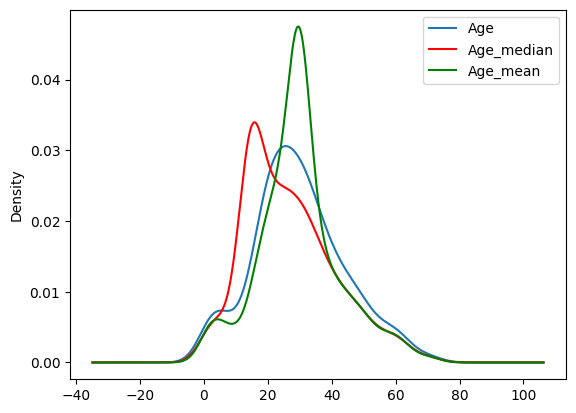

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)
#Original varable distribution
x_train['Age'].plot(kind = 'kde',ax = ax)
#variable imputed with the median
x_train['Age_median'].plot(kind = 'kde',ax =ax,color = 'Red')
#variable imputed with the mean 
x_train['Age_mean'].plot(kind = 'kde',ax =ax,color = 'Green')
#add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines , labels, loc = 'best')

In [16]:
x_train.cov()

,Age,Fare,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,71.512440,204.349513,204.349513,204.349513,204.349513
Fare,71.512440,2368.246832,91.545148,56.626587,91.545148,56.626587
Age_median,204.349513,91.545148,200.550855,161.812625,200.550855,161.812625
Age_mean,204.349513,56.626587,161.812625,161.812625,161.812625,161.812625
Fare_median,204.349513,91.545148,200.550855,161.812625,200.550855,161.812625
Fare_mean,204.349513,56.626587,161.812625,161.812625,161.812625,161.812625


In [17]:
x_train.corr()

,Age,Fare,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.095814,1.000000,1.000000,1.000000,1.000000
Fare,0.095814,1.000000,0.132834,0.091475,0.132834,0.091475
Age_median,1.000000,0.132834,1.000000,0.898243,1.000000,0.898243
Age_mean,1.000000,0.091475,0.898243,1.000000,0.898243,1.000000
Fare_median,1.000000,0.132834,1.000000,0.898243,1.000000,0.898243
Fare_mean,1.000000,0.091475,0.898243,1.000000,0.898243,1.000000


<Axes: >

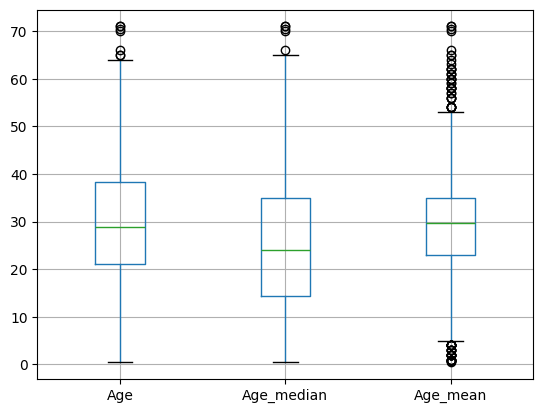

In [18]:
x_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

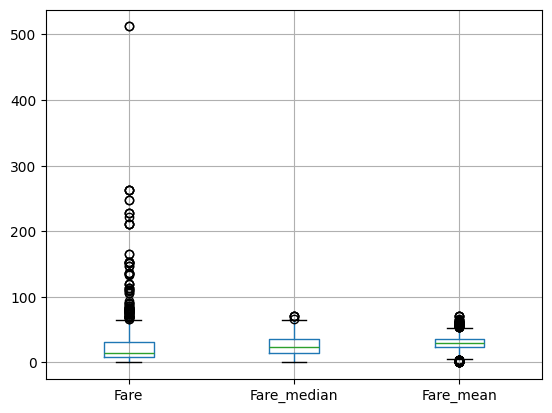

In [19]:
x_train[['Fare','Fare_median','Fare_mean']].boxplot()

**Using Sklearn**

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [21]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')

In [22]:
trf = ColumnTransformer([
    ('imputer1',imputer1,[0]),
    ('imputer2',imputer2,[0])
],remainder = 'passthrough',
  force_int_remainder_cols = False)

In [23]:
trf.fit(x_train)

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 [0]),
                                ('imputer2', SimpleImputer(), [0])])

In [24]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [25]:
trf.named_transformers_['imputer2'].statistics_

array([29.78590426])

In [26]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [27]:
x_train

array([[ 40.        ,  40.        ,  27.7208    ],
       [  4.        ,   4.        ,  16.7       ],
       [ 47.        ,  47.        ,   9.        ],
       ...,
       [ 71.        ,  71.        ,  49.5042    ],
       [ 28.75      ,  29.78590426, 221.7792    ],
       [ 28.75      ,  29.78590426,  25.925     ]])

**Arbitrary Value Imputation**
Mainly used in categorical data.
Missing value is replaced with word 'Missing'.

In [28]:
x_train = pd.DataFrame(x_train)

In [29]:
x_train

,0,1,2
0,40.00,40.000000,27.7208
1,4.00,4.000000,16.7000
2,47.00,47.000000,9.0000
3,9.00,9.000000,31.3875
4,20.00,20.000000,9.8458
...,...,...,...
707,30.00,30.000000,8.6625
708,28.75,29.785904,8.7125
709,71.00,71.000000,49.5042
710,28.75,29.785904,221.7792


In [30]:
x_train.columns = ['Age','Fare','Extra_columns']

In [31]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minus'] = x_train['Age'].fillna(-1)
x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minus1'] = x_train['Fare'].fillna(-1)

In [32]:
x_train.head()

,Age,Fare,Extra_columns,Age_99,Age_minus,Fare_999,Fare_minus1
0,40.0,40.0,27.7208,40.0,40.0,40.0,40.0
1,4.0,4.0,16.7000,4.0,4.0,4.0,4.0
2,47.0,47.0,9.0000,47.0,47.0,47.0,47.0
3,9.0,9.0,31.3875,9.0,9.0,9.0,9.0
4,20.0,20.0,9.8458,20.0,20.0,20.0,20.0


In [33]:
print("Original Age Variable Varience:",x_train['Age'].var())
print("Age varience after median imputation:",x_train['Age_99'].var())
print("Age varience after mean imputation:",x_train['Age_minus'].var())
print("Original Fare Variable Varience:",x_train['Fare'].var())
print("Fare varience after median imputation:",x_train['Fare_999'].var())
print("Age varience after mean imputation:",x_train['Fare_minus1'].var())



Original Age Variable Varience: 161.9895663346054
Age varience after median imputation: 161.9895663346054
Age varience after mean imputation: 161.9895663346054
Original Fare Variable Varience: 161.81262452718673
Fare varience after median imputation: 161.81262452718673
Age varience after mean imputation: 161.81262452718673


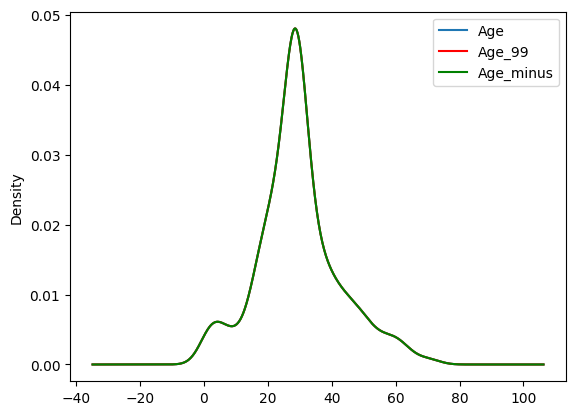

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)
#Original varable distribution
x_train['Age'].plot(kind = 'kde',ax = ax)
#variable imputed with the median
x_train['Age_99'].plot(kind = 'kde',ax =ax,color = 'Red')
#variable imputed with the mean 
x_train['Age_minus'].plot(kind = 'kde',ax =ax,color = 'Green')
#add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines , labels, loc = 'best')

In [35]:
x_train.cov()

,Age,Fare,Extra_columns,Age_99,Age_minus,Fare_999,Fare_minus1
Age,161.989566,161.812625,58.986531,161.989566,161.989566,161.812625,161.812625
Fare,161.812625,161.812625,56.626587,161.812625,161.812625,161.812625,161.812625
Extra_columns,58.986531,56.626587,2368.246832,58.986531,58.986531,56.626587,56.626587
Age_99,161.989566,161.812625,58.986531,161.989566,161.989566,161.812625,161.812625
Age_minus,161.989566,161.812625,58.986531,161.989566,161.989566,161.812625,161.812625
Fare_999,161.812625,161.812625,56.626587,161.812625,161.812625,161.812625,161.812625
Fare_minus1,161.812625,161.812625,56.626587,161.812625,161.812625,161.812625,161.812625


In [36]:
x_train.corr()

,Age,Fare,Extra_columns,Age_99,Age_minus,Fare_999,Fare_minus1
Age,1.000000,0.999454,0.095235,1.000000,1.000000,0.999454,0.999454
Fare,0.999454,1.000000,0.091475,0.999454,0.999454,1.000000,1.000000
Extra_columns,0.095235,0.091475,1.000000,0.095235,0.095235,0.091475,0.091475
Age_99,1.000000,0.999454,0.095235,1.000000,1.000000,0.999454,0.999454
Age_minus,1.000000,0.999454,0.095235,1.000000,1.000000,0.999454,0.999454
Fare_999,0.999454,1.000000,0.091475,0.999454,0.999454,1.000000,1.000000
Fare_minus1,0.999454,1.000000,0.091475,0.999454,0.999454,1.000000,1.000000


<Axes: >

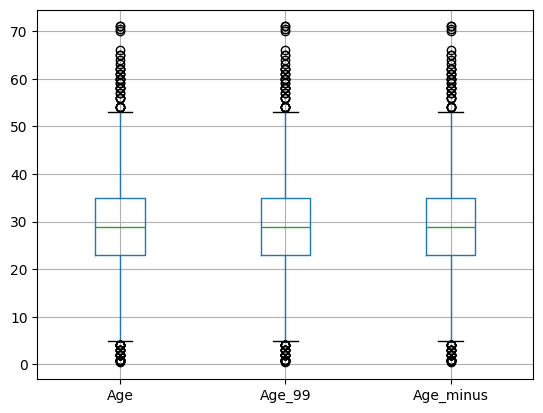

In [37]:
x_train[['Age','Age_99','Age_minus']].boxplot()

<Axes: >

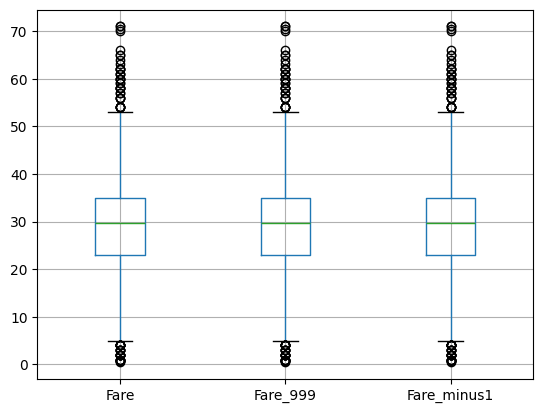

In [38]:
x_train[['Fare','Fare_999','Fare_minus1']].boxplot()

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [40]:
imputer1 = SimpleImputer(strategy = 'constant',fill_value = 99)
imputer2 = SimpleImputer(strategy = 'constant', fill_value = 999)

In [41]:
trf = ColumnTransformer([
    ('imputer1',imputer1,[0]),
    ('imputer2',imputer2,[0])
],remainder = 'passthrough',
  force_int_remainder_cols = False)

In [42]:
trf.fit(x_train)

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 [0]),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 [0])])

In [43]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [44]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [45]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [46]:
x_train

array([[ 40.    ,  40.    ,  27.7208],
       [  4.    ,   4.    ,  16.7   ],
       [ 47.    ,  47.    ,   9.    ],
       ...,
       [ 71.    ,  71.    ,  49.5042],
       [ 99.    , 999.    , 221.7792],
       [ 99.    , 999.    ,  25.925 ]])